In [1]:
import json
import re
from collections import Counter, defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import torch
import torch.nn as nn
from PIL import Image
from torchvision import models, transforms
from ultralytics import YOLO

from feature_lists import full_image_features, full_image_head_features, full_image_person_features


negative_labels = {
    "__MISSING__",
    "нет",
    "отсутствует",
    "отсутствуют",
    "ничего из перечисленного",
    "ничего",
}

excluded_primary_values = {
    "Пол обследуемого = женский",
    "Возраст обследуемого = 7-9",
}

excluded_primary_features = {
    "Пол обследуемого",
    "Возраст обследуемого",
}

excluded_secondary_features = {
    "высокая значимость сексуальной сферы",
}


class CropResult:
    def __init__(self, original, person, head, person_conf, head_conf):
        self.original = original
        self.person = person
        self.head = head
        self.person_conf = person_conf
        self.head_conf = head_conf


class MultiHeadResNet152(nn.Module):
    def __init__(self, head_dims):
        super().__init__()
        backbone = models.resnet152(weights=None)
        in_features = backbone.fc.in_features
        backbone.fc = nn.Identity()
        self.backbone = backbone
        self.heads = nn.ModuleDict(
            {head_name: nn.Linear(in_features, out_dim) for head_name, out_dim in head_dims.items()}
        )

    def forward(self, x):
        feats = self.backbone(x)
        return {name: head(feats) for name, head in self.heads.items()}


def sanitize_text(text):
    text = text.strip()
    text = re.sub(r"[^\w]+", "_", text, flags=re.UNICODE)
    text = re.sub(r"_+", "_", text).strip("_")
    return text


def feature_candidates(feature):
    candidates = {
        feature,
        feature.lower(),
        sanitize_text(feature),
        sanitize_text(feature).lower(),
    }
    return [c for c in candidates if c]


label_rules = {
    "Устойчивость изображенного человека": {
        "неустойчив": [
            "органическое поражение мозга",
            "ощущение внутренней неустойчивости",
            "нарушения умственного развития",
            "эмоциональная нестабильность",
        ],
        "'висит в воздухе'": [
            "органическое поражение мозга",
            "ощущение внутренней неустойчивости",
            "нарушения умственного развития",
            "тревожная дезориентация",
        ],
        "относительно устойчив": ["компенсаторный самоконтроль", "частичная внутренняя опора"],
        "вполне устойчив": ["ощущение внутренней опоры", "достаточная эмоциональная устойчивость"],
    },
    "Рот": {
        "отсутствует": ["негативизм", "аутизация", "астения", "импульсивность", "затрудненное самовыражение"],
        "маленький": ["негативизм", "аутизация", "астения", "импульсивность", "эмоциональная сдержанность"],
        "зачерненный": ["эмоциональная напряженность", "острая тревога", "внутренний конфликт"],
        "усиленный нажим": ["эмоциональная напряженность", "ригидность", "импульсивность", "склонность к жесткому самоконтролю"],
        "средний (стандарт)": [],
        "большой": ["потребность в коммуникации", "аффективная экспрессия", "потребность быть услышанным"],
    },
    "Форма рта": {
        "губы тщательно вырисованы": ["высокая значимость сексуальной сферы", "демонстративность", "потребность в принятии"],
        "контур": ["негативизм", "эмоциональная дистанция", "осторожность в самораскрытии"],
        "черта": ["негативизм", "отрицательное отношение к обследованию", "сдерживание аффекта"],
        "губы без особенностей": [],
        "другое": ["негативизм", "эмоциональная амбивалентность"],
    },
    "Положение рта / губ": {
        "опущены вниз": ["негативизм", "отрицательное отношение к обследованию", "сниженное настроение", "пессимистический фон"],
        "подняты вверх": ["высокая значимость сексуальной сферы", "демонстративность", "ориентация на социальное одобрение"],
        "горизонтально": ["эмоциональная сдержанность", "контроль внешних проявлений"],
        "другое": ["негативизм", "эмоциональная неустойчивость"],
    },
    "Зубы": {
        "острые": ["вербальная агрессия", "агрессивность", "защитная враждебность"],
        "в большом количестве": ["вербальная агрессия", "напряженный самоконтроль"],
        "выделены нажимом": ["вербальная агрессия", "эмоциональная напряженность", "импульсивная разрядка"],
        "нарисованы, без особенностей": ["вербальная агрессия"],
        "другое": ["вербальная агрессия", "внутреннее возбуждение"],
        "отсутствуют": [],
    },
    "Ресницы": {
        "длинные, загнутые": ["демонстративность", "потребность производить приятное впечатление"],
        "имеются, без особенностей": ["демонстративность"],
        "нарисованы небрежно": ["демонстративность", "аффективная поспешность"],
        "другое": ["демонстративность"],
        "отсутствуют": [],
    },
    "Ракурс": {
        "со спины": ["уход от общения", "негативизм", "избегание контакта"],
        "профиль": ["уход от общения", "избирательная дистанция", "избирательная открытость"],
        "полоборота": ["осторожность в контакте"],
        "стандарт (фас)": ["готовность к прямому контакту"],
        "сверху": ["переживание давления со стороны среды", "ощущение уязвимости"],
        "снизу": ["компенсаторное стремление к значимости", "напряженная самопрезентация"],
    },
    "Пол персонажа": {
        "неопределенный": ["тревожность", "неуверенность в себе", "неопределенность ролевой идентичности"],
        "женский": [],
        "мужской": [],
    },
    "Поза": {
        "лежит": ["астения", "сниженная активность", "утомление"],
        "сидит": ["сниженная активность", "выжидательная позиция"],
        "танцует, прыгает и т.п.": ["высокая активность", "импульсивность", "повышенная возбудимость"],
        "идет": ["высокая активность", "творческая направленность", "ориентация на действие"],
        "стоит": ["контроль поведения", "опора на самоконтроль"],
        "бежит": ["внутреннее напряжение", "потребность в быстрой разрядке"],
    },
    "Способ изображения": {
        "условное изображение": ["снижение интеллектуальной продуктивности", "нарушения социализации", "схематизация переживаний"],
        "примитивная схема": ["снижение интеллектуальной продуктивности", "нарушения социализации", "снижение дифференцированности образа"],
        "пластический": ["эмоциональная вовлеченность", "контакт с переживаниями"],
        "дифференцированная схема": ["когнитивная упорядоченность", "способность к структурированию"],
        "промежуточный": [],
        "пластический с элементами схемы": ["смешанный стиль реагирования"],
        "схема с элементами пластического": ["смешанный стиль реагирования"],
        "штриховой": ["внутренняя тревога", "неуверенность в линии поведения"],
    },
    "Размер глаз": {
        "большие": ["повышенная настороженность", "потребность в контроле среды"],
        "маленькие": ["эмоциональная закрытость", "уход в себя"],
        "средние (стандарт)": [],
        "асимметричные": ["внутреннее напряжение", "эмоциональная неравномерность"],
    },
    "Руки (одна или обе)": {
        "две руки в одинаковом положении": ["поведенческая организованность"],
        "две руки в разном положении": ["внутреннее напряжение", "амбивалентность"],
        "отсутствуют": ["тревожность", "затруднение перехода к действию"],
        "только одна рука": ["неуверенность в собственной эффективности"],
        "спрятаны": ["избегание контакта", "осторожность в самопредъявлении"],
    },
    "Ноги (постановка)": {
        "сведены вместе": ["скованность", "тревожная сдержанность"],
        "слегка расставлены (стандарт)": [],
        "широко расставлены": ["потребность в доминировании", "напряженная самозащитная позиция"],
    },
    "Ноги (длина)": {
        "короткие": ["зависимая позиция", "снижение уверенности"],
        "длинные": ["стремление к автономии", "потребность в расширении личного пространства"],
        "средние (стандарт)": [],
    },
    "Размер рисунка": {
        "крупный": ["потребность в заметной самопрезентации", "аффективная экспансивность"],
        "мелкий": ["неуверенность в себе", "тревожная скованность"],
        "стандарт": [],
    },
    "Стирания, исправления": {
        "сильно выражены": ["тревога как состояние на момент обследования", "перфекционизм", "неуверенность в себе"],
        "средняя выраженность": ["эмоциональная напряженность"],
        "слабо выражены": ["умеренная тревожность"],
        "отсутствуют": [],
    },
    "Шея отделена от тела линией": {
        "просто линия": ["потребность в контроле импульсов"],
        "любой предмет, отделяющий шею от тела": ["компенсаторная саморегуляция"],
        "бусы": ["демонстративность"],
        "галстук": ["контроль социального образа", "ориентация на внешний статус"],
        "шея отсутствует": ["импульсивность", "снижение самоконтроля"],
        "ничего из перечисленного": [],
    },
    "Язык": {
        "нарисован": ["импульсивность", "вербальная эмоциональная разрядка"],
        "высунут": ["импульсивность", "демонстративный протест", "снижение самоконтроля"],
        "отсутствует": [],
    },
    "Нажим линий": {
        "сильный": ["эмоциональное напряжение", "внутренняя мобилизация"],
        "слабый": ["астения", "сниженный энергетический тонус"],
        "неравномерный": ["эмоциональная лабильность", "колебания самоконтроля"],
    },
    "Линия основания (земли)": {
        "есть": ["потребность в опоре", "ориентация на реальность"],
        "отсутствует": ["чувство неустойчивости", "переживание отсутствия опоры"],
    },
}


use_generic_for_multiclass = False


ModuleNotFoundError: No module named 'feature_lists'

In [ ]:
def load_json_file(path):
    with path.open("r", encoding="utf-8") as file_handle:
        return json.load(file_handle)


def load_mapping_table(notebook_path):
    notebook_data = load_json_file(notebook_path)
    for cell in notebook_data.get("cells", []):
        if cell.get("cell_type") != "code":
            continue
        source = "".join(cell.get("source", []))
        if "features_to_secondary" in source and "={" in source.replace(" ", ""):
            scope = {}
            exec(source, {}, scope)
            mapping = scope.get("features_to_secondary")
            if isinstance(mapping, dict):
                return mapping
    raise RuntimeError("Не удалось найти features_to_secondary в features_mapping.ipynb")


def find_image_path(images_dir, image_name):
    path_value = Path(image_name)
    if path_value.is_absolute() and path_value.exists():
        return path_value

    base_path = images_dir / image_name
    if base_path.exists():
        return base_path

    stem = base_path.stem
    extensions = [".png", ".jpg", ".jpeg", ".bmp", ".webp", ".tif", ".tiff"]
    for extension in extensions:
        candidate = images_dir / f"{stem}{extension}"
        if candidate.exists():
            return candidate

    raise FileNotFoundError(f"Изображение '{image_name}' не найдено в папке {images_dir}")


def to_pil_image(image_like):
    if isinstance(image_like, Image.Image):
        return image_like.convert("RGB")
    if hasattr(image_like, "shape"):
        return Image.fromarray(image_like[..., ::-1]).convert("RGB")
    raise TypeError("Неподдерживаемый формат изображения для преобразования в PIL")


def pick_box_by_class(result, class_keywords):
    boxes = result.boxes
    if boxes is None or len(boxes) == 0:
        return None

    names = result.names if hasattr(result, "names") else {}
    candidates = []

    for index in range(len(boxes)):
        class_id = int(boxes.cls[index].item()) if boxes.cls is not None else -1
        conf = float(boxes.conf[index].item()) if boxes.conf is not None else 0.0
        class_name = str(names.get(class_id, "")).lower()
        if any(keyword in class_name for keyword in class_keywords):
            coords = boxes.xyxy[index].tolist()
            area = max(0.0, (coords[2] - coords[0]) * (coords[3] - coords[1]))
            candidates.append((area, coords, conf))

    if not candidates:
        return None

    candidates.sort(key=lambda item: item[0], reverse=True)
    _, coords, conf = candidates[0]
    return coords, conf


def pick_largest_box(result):
    boxes = result.boxes
    if boxes is None or len(boxes) == 0:
        return None

    best_item = None
    for index in range(len(boxes)):
        coords = boxes.xyxy[index].tolist()
        conf = float(boxes.conf[index].item()) if boxes.conf is not None else 0.0
        area = max(0.0, (coords[2] - coords[0]) * (coords[3] - coords[1]))
        if best_item is None or area > best_item[0]:
            best_item = (area, coords, conf)

    if best_item is None:
        return None

    _, coords, conf = best_item
    return coords, conf


def crop_by_coords(image, coords):
    width, height = image.size
    x1, y1, x2, y2 = [int(round(value)) for value in coords]
    x1 = max(0, min(x1, width - 1))
    y1 = max(0, min(y1, height - 1))
    x2 = max(x1 + 1, min(x2, width))
    y2 = max(y1 + 1, min(y2, height))
    return image.crop((x1, y1, x2, y2))


def detect_and_crop(yolo_model_path, image_path):
    yolo_model = YOLO(str(yolo_model_path))
    result = yolo_model(str(image_path), verbose=False)[0]
    original = to_pil_image(result.orig_img)

    person_pick = pick_box_by_class(result, ("person", "human", "персонаж", "человек"))
    head_pick = pick_box_by_class(result, ("head", "face", "голова", "лицо"))

    if person_pick is None:
        person_pick = pick_largest_box(result)
    if person_pick is None:
        raise RuntimeError("YOLO не нашла ни одного объекта для кропа персонажа")

    person_coords, person_conf = person_pick
    person_crop = crop_by_coords(original, person_coords)

    if head_pick is None:
        person_width, person_height = person_crop.size
        head_crop = person_crop.crop((0, 0, person_width, max(1, int(person_height * 0.45))))
        head_conf = None
    else:
        head_coords, head_conf = head_pick
        head_crop = crop_by_coords(original, head_coords)

    return CropResult(
        original=original,
        person=person_crop,
        head=head_crop,
        person_conf=person_conf,
        head_conf=head_conf,
    )


def show_and_save_triplet_plot(crops, save_path, show_plot=True):
    figure, axes = plt.subplots(1, 3, figsize=(14, 5))

    axes[0].imshow(crops.original)
    axes[0].set_title("Оригинальное изображение")

    axes[1].imshow(crops.person)
    person_title = "Кроп персонажа"
    if crops.person_conf is not None:
        person_title += f"\nconf={crops.person_conf:.3f}"
    axes[1].set_title(person_title)

    axes[2].imshow(crops.head)
    head_title = "Кроп головы"
    if crops.head_conf is not None:
        head_title += f"\nconf={crops.head_conf:.3f}"
    axes[2].set_title(head_title)

    for axis in axes:
        axis.axis("off")

    plt.tight_layout()
    figure.savefig(save_path, dpi=150)

    if show_plot:
        plt.show()

    plt.close(figure)

In [ ]:
def extract_head_dims(state_dict):
    head_dims = {}
    for key, value in state_dict.items():
        match = re.match(r"^heads\.([^\.]+)\.weight$", key)
        if match and value.ndim == 2:
            head_dims[match.group(1)] = int(value.shape[0])
    return head_dims


def map_heads_to_features(head_names, targets, checkpoint_data):
    if len(head_names) != len(targets):
        raise RuntimeError(
            f"Количество head-ов ({len(head_names)}) не совпадает с количеством targets ({len(targets)})."
        )

    for key in ("head_to_feature", "head2feature", "feature_names", "targets"):
        value = checkpoint_data.get(key)
        if isinstance(value, dict) and all(head in value for head in head_names):
            return {head: str(value[head]) for head in head_names}
        if isinstance(value, list) and len(value) == len(head_names):
            return {head: str(feature) for head, feature in zip(head_names, value)}

    index_map = {}
    is_indexed = True
    for head in head_names:
        match = re.search(r"(\d+)$", head)
        if not match:
            is_indexed = False
            break
        index_map[head] = int(match.group(1))

    if is_indexed and len(set(index_map.values())) == len(targets):
        ordered_heads = sorted(head_names, key=lambda item: index_map[item])
        return {head: targets[index] for index, head in enumerate(ordered_heads)}

    target_candidates = {target: set(feature_candidates(target)) for target in targets}
    mapping = {}
    used_targets = set()

    for head in head_names:
        lower_head = head.lower()
        matched_target = None
        for target, candidates in target_candidates.items():
            if target in used_targets:
                continue
            if head in candidates or lower_head in candidates:
                matched_target = target
                break
        if matched_target is not None:
            mapping[head] = matched_target
            used_targets.add(matched_target)

    if len(mapping) == len(head_names):
        return mapping

    ordered_heads = sorted(head_names)
    return {head: targets[index] for index, head in enumerate(ordered_heads)}


def load_resnet_model(checkpoint_path, schema_path, device):
    schema = load_json_file(schema_path)
    checkpoint_data = torch.load(checkpoint_path, map_location=device)

    if isinstance(checkpoint_data, nn.Module):
        model = checkpoint_data.to(device).eval()
        return model, {"schema": schema, "head_to_feature": None}

    if not isinstance(checkpoint_data, dict):
        raise RuntimeError(f"Неизвестный формат чекпойнта: {type(checkpoint_data)}")

    model_object = checkpoint_data.get("model")
    if isinstance(model_object, nn.Module):
        model_object = model_object.to(device).eval()
        return model_object, {"schema": schema, "head_to_feature": None}

    state_dict = checkpoint_data.get("model_state_dict", checkpoint_data)
    if not isinstance(state_dict, dict):
        raise RuntimeError("В чекпойнте отсутствует model_state_dict")

    head_dims = extract_head_dims(state_dict)
    if not head_dims:
        raise RuntimeError(f"Не найден формат heads.*.weight в {checkpoint_path.name}")

    model = MultiHeadResNet152(head_dims).to(device)
    model.load_state_dict(state_dict, strict=True)
    model.eval()

    head_to_feature = map_heads_to_features(list(head_dims.keys()), schema["targets"], checkpoint_data)
    return model, {"schema": schema, "head_to_feature": head_to_feature}


def build_transform():
    return transforms.Compose(
        [
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ]
    )


def decode_predictions(logits_dict, schema, head_to_feature):
    rows = []
    feature_meta = schema["features"]

    for head_name, logits in logits_dict.items():
        feature = head_to_feature[head_name]
        feature_info = feature_meta[feature]
        probs = torch.softmax(logits, dim=-1).detach().cpu().tolist()
        id_to_label = feature_info["id2label"]

        for index, prob in enumerate(probs):
            rows.append(
                {
                    "feature": feature,
                    "label": id_to_label[str(index)],
                    "probability": float(prob),
                    "num_labels": int(feature_info["num_labels"]),
                }
            )

    return rows


def model_predict(model, model_meta, image, model_name, device, transform_pipe):
    input_tensor = transform_pipe(image).unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(input_tensor)

    if not isinstance(output, dict):
        raise RuntimeError(f"Ожидался dict-выход модели ({model_name}), получен {type(output)}")

    head_to_feature = model_meta.get("head_to_feature")
    if not head_to_feature:
        head_to_feature = {key: key for key in output.keys()}

    logits_dict = {key: value[0] for key, value in output.items()}
    decoded = decode_predictions(logits_dict, model_meta["schema"], head_to_feature)

    for row in decoded:
        row["model"] = model_name

    return decoded

In [ ]:
def resolve_primary_secondary(feature, label, num_labels, mapping):
    if label in negative_labels:
        return "", []

    mapping_keys = set(mapping.keys())
    candidates = [f"{feature} ({label})", f"{feature}: {label}"]

    match = re.match(r"^(.*)\(([^()]*)\)\s*$", feature)
    if match:
        base_feature = match.group(1).strip()
        candidates.insert(0, f"{base_feature} ({label})")

    if feature.lower().startswith("пол персонажа"):
        candidates.insert(0, f"Пол ({label})")

    for candidate in candidates:
        if candidate in mapping_keys:
            return candidate, mapping.get(candidate, [])

    rules_for_feature = label_rules.get(feature, {})
    if label in rules_for_feature:
        return f"{feature} ({label})", rules_for_feature[label]

    if num_labels > 2 and not use_generic_for_multiclass:
        return f"{feature} ({label})", []

    if feature in mapping_keys:
        return feature, mapping.get(feature, [])

    return f"{feature} ({label})", []


configured_feature_sets = {
    "full_image": set(full_image_features),
    "person_crop": set(full_image_person_features),
    "head_crop": set(full_image_head_features),
}


def infer_feature_domain(feature):
    if feature in configured_feature_sets["head_crop"]:
        return "head"

    if feature in configured_feature_sets["person_crop"]:
        return "body"

    return "global"


def build_model_feature_sets(model_meta_by_name):
    model_feature_sets = {}
    for model_name, model_meta in model_meta_by_name.items():
        targets = set(model_meta.get("schema", {}).get("targets", []))
        configured_targets = configured_feature_sets.get(model_name, set())

        if configured_targets:
            model_feature_sets[model_name] = targets & configured_targets
        else:
            model_feature_sets[model_name] = targets

    return model_feature_sets


def preferred_model_for_feature(feature):
    feature_text = str(feature)
    if feature_text.lower().startswith("Расположение на листе"):
        return "full_image"

    if feature in configured_feature_sets["head_crop"]:
        return "head_crop"

    if feature in configured_feature_sets["person_crop"]:
        return "person_crop"

    return "full_image"


def is_model_allowed_for_feature(feature, model_name, model_feature_sets):
    if model_name not in model_feature_sets:
        return False

    if feature not in model_feature_sets.get(model_name, set()):
        return False

    preferred_model = preferred_model_for_feature(feature)
    return model_name == preferred_model


def aggregate_primary_predictions(rows, mapping, threshold, model_feature_sets=None):
    best = {}

    for row in rows:
        prob = float(row["probability"])
        if prob < threshold:
            continue

        primary, secondary = resolve_primary_secondary(
            feature=row["feature"],
            label=row["label"],
            num_labels=int(row.get("num_labels", 2)),
            mapping=mapping,
        )
        if not primary:
            continue

        primary_with_value = format_primary_with_value(primary, row["label"])
        base_primary_feature = extract_base_primary_feature(primary_with_value)

        if primary_with_value in excluded_primary_values:
            continue
        if base_primary_feature in excluded_primary_features:
            continue

        if not is_model_allowed_for_feature(
            feature=row["feature"],
            model_name=row["model"],
            model_feature_sets=model_feature_sets or {},
        ):
            continue

        secondary = [item for item in secondary if item not in excluded_secondary_features]

        selection_score = prob

        if primary not in best or selection_score > best[primary]["selection_score"]:
            best[primary] = {
                "primary_feature": primary,
                "probability": prob,
                "source_model": row["model"],
                "source_feature": row["feature"],
                "source_label": row["label"],
                "secondary_features": secondary,
                "selection_score": selection_score,
            }

    if not best:
        return pd.DataFrame(
            columns=[
                "primary_feature",
                "probability",
                "source_model",
                "source_feature",
                "source_label",
                "secondary_features",
                "selection_score",
            ]
        )

    return pd.DataFrame(best.values()).sort_values("probability", ascending=False)


def format_primary_with_value(primary_feature, source_label):
    primary_text = str(primary_feature)
    label_text = str(source_label)

    suffix_parentheses = f" ({label_text})"
    suffix_colon = f": {label_text}"

    if primary_text.endswith(suffix_parentheses):
        primary_text = primary_text[: -len(suffix_parentheses)]
    elif primary_text.endswith(suffix_colon):
        primary_text = primary_text[: -len(suffix_colon)]

    return f"{primary_text} = {label_text}"


def extract_base_primary_feature(primary_with_value):
    text = str(primary_with_value)
    if " = " in text:
        return text.split(" = ", 1)[0].strip()
    return text.strip()


def quote_primary_with_value(primary_with_value):
    text = str(primary_with_value)
    if " = " in text:
        left, right = text.split(" = ", 1)
        return f"\"{left}\" = \"{right}\""
    return f"\"{text}\""


def aggregate_secondary_votes(primary_table):
    votes = defaultdict(list)

    for _, row in primary_table.iterrows():
        primary_with_value = format_primary_with_value(row["primary_feature"], row["source_label"])
        primary_with_value_quoted = quote_primary_with_value(primary_with_value)
        for secondary in row["secondary_features"]:
            votes[secondary].append((primary_with_value_quoted, float(row["probability"])))

    records = []
    for secondary, supporters in votes.items():
        sorted_supporters = sorted(supporters, key=lambda item: item[1], reverse=True)
        records.append(
            {
                "secondary_feature": secondary,
                "votes_count": len(sorted_supporters),
                "supporters": [f"{primary} ({prob:.3f})" for primary, prob in sorted_supporters],
            }
        )

    if not records:
        return pd.DataFrame(columns=["secondary_feature", "votes_count", "supporters"])

    return pd.DataFrame(records).sort_values(["votes_count", "secondary_feature"], ascending=[False, True])


def print_model_predictions(rows, threshold=0.0):
    print("\nПредсказания по моделям:")

    grouped = defaultdict(dict)
    for row in rows:
        if row["label"] in negative_labels:
            continue

        model_name = row["model"]
        feature_name = row["feature"]
        prob = float(row["probability"])

        if feature_name not in grouped[model_name] or prob > grouped[model_name][feature_name]["probability"]:
            grouped[model_name][feature_name] = row

    for model_name in ["full_image", "person_crop", "head_crop"]:
        feature_rows = list(grouped.get(model_name, {}).values())
        feature_rows = [row for row in feature_rows if float(row["probability"]) >= threshold]
        feature_rows = sorted(feature_rows, key=lambda item: float(item["probability"]), reverse=True)

        print(f"\n[{model_name}] {len(feature_rows)} признаков >= {threshold}")
        if not feature_rows:
            print("  Нет предсказаний выше порога.")
            continue

        for row in feature_rows:
            primary_with_value = format_primary_with_value(row["feature"], row["label"])
            primary_with_value_quoted = quote_primary_with_value(primary_with_value)
            print(f"  ({row['probability']:.3f}) {primary_with_value_quoted}")


def print_secondary_matching(secondary_table):
    print("\nCопоставление первичных и вторичных признаков:")
    if secondary_table.empty:
        print("Нет вторичных признаков.")
    else:
        for _, row in secondary_table.iterrows():
            print(f"\"{row['secondary_feature']}\" {row['votes_count']}: {row['supporters']}")


def print_reports(primary_table, secondary_table):
    print("\nПервичные признаки и их вторичные:")
    if primary_table.empty:
        print("Нет первичных признаков выше порога.")
    else:
        for _, row in primary_table.iterrows():
            primary_with_value = format_primary_with_value(row["primary_feature"], row["source_label"])
            primary_with_value_quoted = quote_primary_with_value(primary_with_value)
            print(f"({row['probability']:.3f}) {primary_with_value_quoted}: {row['secondary_features']}")

    print_secondary_matching(secondary_table)

In [ ]:
def run_pipeline(image_name, threshold=0.7, output_dir="pipeline_output", show_crops=True):
    root = Path.cwd()
    images_dir = root / "images"
    resnets_dir = root / "resnets"
    yolo_path = root / "yolo_3000.pt"
    mapping_notebook = root / "features_mapping.ipynb"
    result_dir = root / output_dir
    result_dir.mkdir(parents=True, exist_ok=True)

    image_path = find_image_path(images_dir, image_name)
    mapping = load_mapping_table(mapping_notebook)

    crops = detect_and_crop(yolo_path, image_path)
    show_and_save_triplet_plot(
        crops,
        result_dir / f"{image_path.stem}_triplet.png",
        show_plot=show_crops,
    )

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    transform_pipe = build_transform()

    model_configs = [
        (
            "full_image",
            resnets_dir / "resnet152_full_image_output" / "resnet152_full_image_multitask.pth",
            resnets_dir / "resnet152_full_image_output" / "progress_json" / "feature_schema.json",
            crops.original,
        ),
        (
            "person_crop",
            resnets_dir / "resnet152_person_output" / "resnet152_person_multitask.pth",
            resnets_dir / "resnet152_person_output" / "progress_json" / "feature_schema.json",
            crops.person,
        ),
        (
            "head_crop",
            resnets_dir / "resnet152_head_output" / "resnet152_head_multitask.pth",
            resnets_dir / "resnet152_head_output" / "progress_json" / "feature_schema.json",
            crops.head,
        ),
    ]

    all_rows = []
    model_meta_by_name = {}

    for model_name, checkpoint_path, schema_path, image in model_configs:
        model, model_meta = load_resnet_model(checkpoint_path, schema_path, device)
        model_meta_by_name[model_name] = model_meta
        rows = model_predict(model, model_meta, image, model_name, device, transform_pipe)
        all_rows.extend(rows)

    model_feature_sets = build_model_feature_sets(model_meta_by_name)

    all_model_features = set().union(*model_feature_sets.values()) if model_feature_sets else set()
    print("\nПокрытие признаков моделями:")
    for model_name in ["full_image", "person_crop", "head_crop"]:
        model_features = model_feature_sets.get(model_name, set())
        other_features = all_model_features - model_features
        unique_features = model_features - other_features
        print(
            f"- {model_name}: всего {len(model_features)} признаков, уникальных {len(unique_features)}"
        )

    raw_table = pd.DataFrame(all_rows).sort_values(["feature", "probability"], ascending=[True, False])
    raw_table.to_csv(result_dir / f"{image_path.stem}_raw_model_predictions.csv", index=False, encoding="utf-8-sig")

    print_model_predictions(all_rows, threshold=threshold)

    primary_table = aggregate_primary_predictions(
        all_rows,
        mapping,
        threshold=threshold,
        model_feature_sets=model_feature_sets,
    )
    primary_table.to_csv(result_dir / f"{image_path.stem}_primary_predictions.csv", index=False, encoding="utf-8-sig")

    secondary_table = aggregate_secondary_votes(primary_table)
    secondary_table.to_csv(result_dir / f"{image_path.stem}_secondary_votes.csv", index=False, encoding="utf-8-sig")

    with (result_dir / f"{image_path.stem}_secondary_votes.json").open("w", encoding="utf-8") as file_handle:
        json.dump(secondary_table.to_dict(orient="records"), file_handle, ensure_ascii=False, indent=2)

    print_reports(primary_table, secondary_table)

    if show_crops:
        show_and_save_triplet_plot(
            crops,
            result_dir / f"{image_path.stem}_triplet.png",
            show_plot=True,
        )
    print_secondary_matching(secondary_table)

In [ ]:
def normalize_secondary_term(text):
    text = text.strip().lower()
    text = text.replace("ё", "е")
    text = re.sub(r"\(.*?\)", "", text)
    text = re.sub(r"\b(иногда|обычно|возможно|часто)\b", "", text)
    text = re.sub(r"[^\w\s-]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


def audit_mapping_vs_venger(root=None):
    root_path = root or Path.cwd()
    md_path = root_path / "(Венгер) первичные признаки ко вторичным.md"
    mapping_notebook = root_path / "features_mapping.ipynb"

    mapping = load_mapping_table(mapping_notebook)

    mapped_secondaries = set()
    for secondary_list in mapping.values():
        for item in secondary_list:
            mapped_secondaries.add(normalize_secondary_term(item))

    for feature_rules in label_rules.values():
        for secondary_list in feature_rules.values():
            for item in secondary_list:
                mapped_secondaries.add(normalize_secondary_term(item))

    md_text = md_path.read_text(encoding="utf-8")
    md_secondaries = []

    for line in md_text.splitlines():
        line = line.strip()
        if line.startswith("-"):
            payload = line.lstrip("-").strip()
            if payload and len(payload.split()) <= 12:
                parts = re.split(r"[;,]", payload)
                for part in parts:
                    normalized = normalize_secondary_term(part)
                    if normalized:
                        md_secondaries.append(normalized)

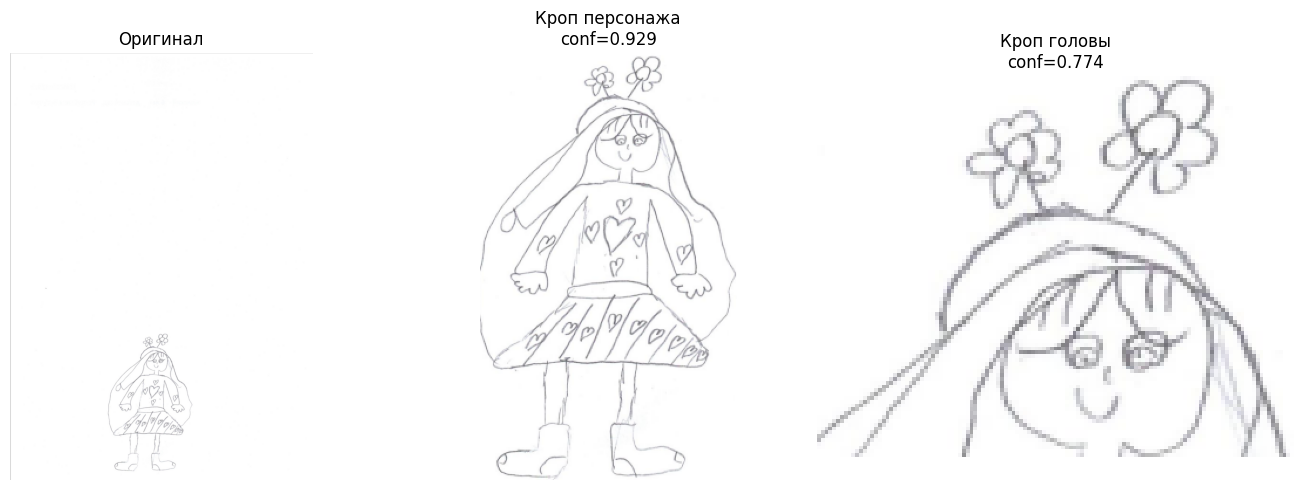


Покрытие признаков моделями:
- full_image: всего 146 признаков, уникальных 146
- person_crop: всего 115 признаков, уникальных 115
- head_crop: всего 63 признаков, уникальных 63

Предсказания по моделям:

[full_image] 28 признаков >= 0.7
  (0.999) "Детали (лицо)" = "глаза (один или оба)"
  (0.997) "Детали (лицо)" = "рот"
  (0.996) "Детали (лицо)" = "волосы (шапка)"
  (0.990) "Ноги (одна или обе) (положение)" = "две ноги в одинаковом положении"
  (0.990) "Расположение на листе" = "смещение вниз"
  (0.987) "Ракурс" = "стандарт (фас)"
  (0.985) "Поза" = "стоит"
  (0.970) "Пол персонажа" = "женский"
  (0.958) "Два глаза одинаковые" = "да"
  (0.954) "Дополнительные детали изображения фигуры" = "украшения"
  (0.947) "Нажим" = "без особенностей"
  (0.943) "Устойчивость изображенного человека" = "вполне устойчив"
  (0.929) "Детали (лицо)" = "лоб"
  (0.917) "Размер глаз" = "средние (стандарт)"
  (0.912) "Голова" = "без особенностей"
  (0.909) "Пол обследуемого" = "женский"
  (0.880) "Положение 

In [ ]:
# image_name = "БО_МШ_22.png"
image_name = "БО_Д_45.png"
threshold = 0.7
output_dir = "pipeline_output"

run_pipeline(
    image_name=image_name,
    threshold=threshold,
    output_dir=output_dir,
)